In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [2]:
non_rag_results = pd.read_json("outputs/evaluated_questions_non-rag.json")
rag_results = pd.read_json("./outputs/evaluated_questions_rag.json")
questions = pd.read_json("./questions.json")

In [3]:
combined_results = (
    questions
    .merge(non_rag_results[["question", "answer", "rating"]].rename(columns={"answer": "non_rag_answer", "rating": "non_rag_rating"}), on="question", how="left")
    .merge(rag_results[["question", "answer", "rating"]].rename(columns={"answer": "rag_answer", "rating": "rag_rating"}), on="question", how="left")
)

In [4]:
combined_results["delta_rating"] = combined_results["rag_rating"] - combined_results["non_rag_rating"]

In [37]:
combined_results.head()

,question,answer,difficulty,category,non_rag_answer,non_rag_rating,rag_answer,rag_rating,delta_rating,q_idx
0,When is Penny's birthday and who's her mom?,Penny's birthday is Fall 2. Her mother is Pam.,easy,characters,- Penny's birthday: Spring 2\n- Penny's mom: Pam,3,"Penny's birthday is Fall 2, and her mother is ...",5,2,0
1,What gifts does Haley love? I keep giving her ...,Haley's four NPC-specific loved gifts are Coco...,medium,characters,Haley’s loved gifts (three items she loves) ar...,3,I don’t know. The Haley pages describe how she...,1,-2,1
2,I'm confused about Sebastian's family — how is...,Robin is Sebastian's mother and Maru's mother....,easy,characters,- Robin and Demetrius are Sebastian’s parents....,3,Sebastian’s relationships with them are:\n- Ro...,4,1,2
3,I got a heart event with Caroline and she taug...,Caroline teaches the player the Tea Sapling re...,hard,characters,"I can help, but I’m missing a detail that chan...",2,- The recipe is Parsnip Soup. This is sent to ...,2,0,3
4,How much does Starfruit sell for and how long ...,Starfruit has a base sell price of 750g. It ta...,easy,farming,- Selling price: 750 gold per Starfruit (at ba...,3,- Sell price: 750g (base price). \n- Growth ti...,5,2,0


**Scores:**  
5 = Fully correct AND equally or more specific than the reference answer  
4 = Correct and useful, but less specific (e.g. "in the mines" when the 
    reference says "levels 40-79 of the mines") — no wrong information  
3 = Partially correct — gets the gist but missing important details, 
    or correct on some points but wrong on others  
2 = Mostly wrong, but contains a grain of relevant truth  
1 = Completely wrong, irrelevant, or nonsensical  

(0.0, 9.45)

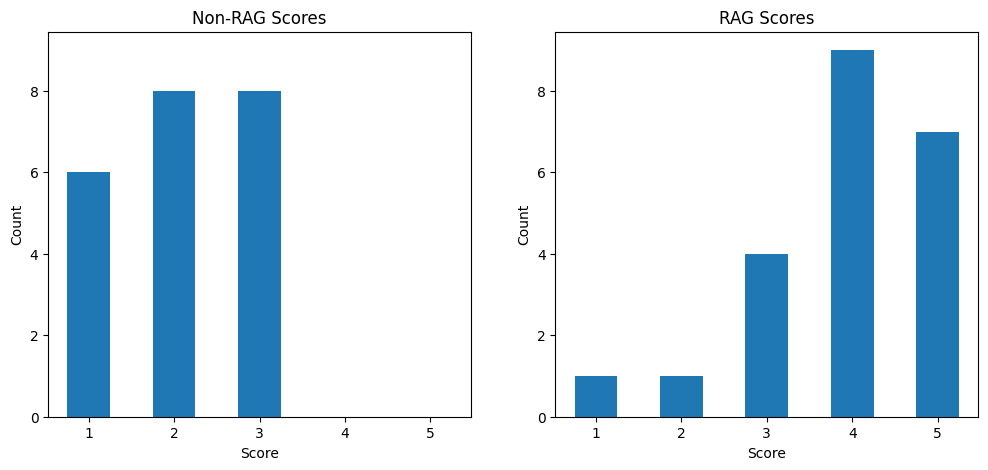

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(combined_results["non_rag_rating"], rwidth=0.5, bins = np.arange(0.5, 6.5, 1))
ax1.set_xlabel("Score")
ax1.set_ylabel("Count")
ax1.set_xticks(np.arange(1, 6))
ax1.set_title("Non-RAG Scores")

ax2.hist(combined_results["rag_rating"], rwidth=0.5, bins = np.arange(0.5, 6.5, 1))
ax2.set_xticks(np.arange(1, 6))
ax2.set_xlabel("Score")
ax2.set_ylabel("Count")
ax2.set_title("RAG Scores")

ymax = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(0, ymax)
ax2.set_ylim(0, ymax)

In [7]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# i mean matplotlib is nice and all.. but
# interactive plots :D
fig = make_subplots(rows=1, cols=2, subplot_titles=("Non-RAG Scores", "RAG Scores"))
fig.add_trace(go.Histogram(x=combined_results["non_rag_rating"], marker_color="steelblue",name="Non-RAG"), row=1, col=1)
fig.add_trace(go.Histogram(x=combined_results["rag_rating"], marker_color="steelblue", name="RAG"), row=1, col=2)
fig.update_layout(bargap=0.2, showlegend=False)
fig.update_xaxes(dtick=1, range=[0.5, 5.5])


In [8]:
fig = px.histogram(combined_results, x="delta_rating", title="Points gained/lost with RAG")
fig.update_layout(bargap=0.2, showlegend=False)

In [9]:
combined_results[combined_results["delta_rating"] == -2]

,question,answer,difficulty,category,non_rag_answer,non_rag_rating,rag_answer,rag_rating,delta_rating
1,What gifts does Haley love? I keep giving her ...,Haley's four NPC-specific loved gifts are Coco...,medium,characters,Haley’s loved gifts (three items she loves) ar...,3,I don’t know. The Haley pages describe how she...,1,-2


In [21]:
combined_results["q_idx"] = combined_results.groupby("category").cumcount()
pivot_custom = combined_results.pivot_table(
    index="category", columns="q_idx",
    values=["question", "rag_answer", "non_rag_answer", "answer"],
    aggfunc="first"
)

fig = px.imshow(
    combined_results.pivot(index="category", columns="q_idx", values="delta_rating"),
    color_continuous_scale="RdYlGn",
    zmin=-4, zmax=4,
    aspect="auto",
    labels={"color": "RAG Gain"},
    title="RAG Score Gain per Category"
)

fig.update_traces(
    customdata=pivot_custom["question"],
    hovertemplate="<b>%{customdata}</b><br>" +
                  "RAG Gain: %{z}<extra></extra>"
)

fig.update_xaxes(visible=False)
fig.update_layout(plot_bgcolor="rgba(0,0,0,0)")
fig.show()

In [38]:
import ipywidgets
import plotly.graph_objects as go

rdylgn = px.colors.diverging.RdYlGn
custom_scale = [[0, "#fff"]] + [
    [0.1 + 0.9 * i / (len(rdylgn) - 1), c] for i, c in enumerate(rdylgn)
]

# Build the pivot data
pivot_delta = combined_results.pivot(index="category", columns="q_idx", values="delta_rating").fillna(-5)

# Create FigureWidget directly (not converted from px)
fig_widget = go.FigureWidget()

# Add the heatmap
fig_widget.add_trace(go.Heatmap(
    z=pivot_delta.values,
    x=list(range(pivot_delta.shape[1])),
    y=pivot_delta.index.tolist(),
    colorscale=custom_scale,
    zmin=-4, zmax=4,
    hoverinfo="skip",
    colorbar=dict(title="RAG Gain"),
))

# Build scatter grid on top of heatmap cells
rows, cols_list = [], []
customdata_flat, z_flat = [], []
rag_flat, non_rag_flat, answer_flat = [], [], []
for i, cat in enumerate(pivot_delta.index):
    for j in range(pivot_delta.shape[1]):
        rows.append(cat)
        cols_list.append(j)
        z_flat.append(pivot_delta.values[i][j])
        customdata_flat.append(pivot_custom["question"].values[i][j])
        rag_flat.append(pivot_custom["rag_answer"].values[i][j])
        non_rag_flat.append(pivot_custom["non_rag_answer"].values[i][j])
        answer_flat.append(pivot_custom["answer"].values[i][j])

fig_widget.add_trace(go.Scatter(
    x=cols_list, y=rows,
    mode="markers",
    marker=dict(size=30, opacity=0),
    hoverinfo="none",
))

fig_widget.update_xaxes(title="Question number")
fig_widget.update_layout(
    title="RAG Score Gain per Category (click for details)",
    plot_bgcolor="rgba(0,0,0,0)",
    showlegend=False,
    height=500,
    yaxis=dict(autorange="reversed"),
)

output = ipywidgets.HTML("")

def on_click(trace, points, state):
    if not points.point_inds:
        return
    idx = points.point_inds[0]
    cat = rows[idx]
    q = customdata_flat[idx]
    delta = z_flat[idx]
    rag = rag_flat[idx]
    non_rag = non_rag_flat[idx]
    correct = answer_flat[idx]
    output.value = f"""
    <div style="padding:10px; border:1px solid #ccc; max-width:800px;">
        <b>Category:</b> {cat}<br>
        <b>Question:</b> {q}<br>
        <b>Delta:</b> {delta}<br><br>
        <b>Correct Answer:</b><br>{correct}<br><br>
        <b>RAG Answer:</b><br>{rag}<br><br>
        <b>Non-RAG Answer:</b><br>{non_rag}
    </div>
    """

# Attach on_click to the scatter trace (index 1), not the heatmap
fig_widget.data[1].on_click(on_click)

display(fig_widget)
display(output)

FigureWidget({
    'data': [{'colorbar': {'title': {'text': 'RAG Gain'}},
              'colorscale': [[0, '#fff'], [0.1, 'rgb(165,0,38)'], [0.19,
                             'rgb(215,48,39)'], [0.28, 'rgb(244,109,67)'], [0.37,
                             'rgb(253,174,97)'], [0.45999999999999996,
                             'rgb(254,224,139)'], [0.55, 'rgb(255,255,191)'],
                             [0.64, 'rgb(217,239,139)'], [0.73,
                             'rgb(166,217,106)'], [0.82, 'rgb(102,189,99)'],
                             [0.9099999999999999, 'rgb(26,152,80)'], [1.0,
                             'rgb(0,104,55)']],
              'hoverinfo': 'skip',
              'type': 'heatmap',
              'uid': 'f27c8804-57ea-40e1-ad19-4fa2a1b35e60',
              'x': [0, 1, 2, 3, 4, 5],
              'y': [characters, farming, lore, mechanics, niche],
              'z': {'bdata': ('AAAAAAAAAEAAAAAAAAAAwAAAAAAAAP' ... 'AAAAAAAEAAAAAAAAAUwAAAAAAAABTA'),
                    'd

HTML(value='')